In [57]:
using LinearAlgebra
using Plots
using Statistics
using LaTeXStrings

# Questão 1. Cálculo dos refletores

$(a)$ Temos $Q_vx=||x||_2e_1$, então:
$$(I−\beta vv^*)x=||x||_2e_1$$

$$\beta(v^*x)v = x - ||x||_2e_1$$

como $\beta(v^*x)$ é um escalar, estamos interessados somente na direção do vetor. podemos escolher:
$$v = x - ||x||_2e_1$$

Para isso, queremos $\beta(v^*x) = 1$. substituindo:
$$v^*x = (x - ||x||_2 e_1)^* x = ||x||_2^2 - ||x||_2x_1$$
$$= ||x||_2(||x||_2 - x_1)$$

Portanto:
$$\beta = \frac{1}{||x||_2(||x||_2 - x_1)}$$

Queremos obter as outras formas de calcular $\beta$:
$$\beta = \frac{1}{||x||_2(||x||_2 - x_1)} \cdot \frac{||x||_2 + x_1}{||x||_2 + x_1} = \frac{||x||_2 + x_1}{||x||_2(||x||_2^2 - x_1^2)}$$

Observe que:
$$||x||_2^2 = x_1^2 + x_2^2 + \dots + x_n^2$$
$$||x||_2^2 - x_1^2 = x_2^2 + \dots + x_n^2 = ||y||_2^2$$

Substituindo:
$$\beta = \frac{||x||_2 + x_1}{||x||_2(||x||_2^2 - x_1^2)} = \frac{||x||_2 + x_1}{||x||_2 \cdot ||y||_2^2}$$

---

$(b)$ Cancelamento numérico ocorre quando subtraímos dois números quase iguais. O resultado tem muito menos dígitos significativos do que os operandos.

Pensando no caso em que $x_1 > 0$ e $x$ está praticamente alinhado com $e_1$, ou seja:
$$ x \approx ||x||_2e_1 \Rightarrow ||x||_2 - x_1 \approx 0, ||x||_2^2 - x_1^2 \approx 0$$

se utlizarmos a primeira ou a segunda fórmula, teremos cancelamento numérico no denominador. Mas $||x||_2 + x_1$ nunca cancela. Assim, a terceira é a melhor opção nesse caso.

No caso em que $x_1 < 0$, tanto a fórmula 3 quanto a fórmula 2 não é uma boa escolha pois:
$$ x \approx -||x||_2e_1 \Rightarrow ||x||_2 + x_1 \approx 0, \ ||x||_2^2 - x_1^2 \approx 0$$

A melhor opção nesse caso é a primeira fórmula, onde não há cancelamento.

---

$(c)$ Utilizando os resultados obtidos nos itens anteiores, temos essa função abaixo

In [58]:
function reflector(x)
    norm_x = norm(x)

    v = copy(x)
    v[1] -= norm_x # muda somente a primeira coordenada

    if x[1] >= 0
        norm_y2 = sum(xi^2 for xi in x[2:end])  # ||y||² direto, sem cancelamento
        # se está exatamente alinhado com e1
        if norm_y2 == 0
            return zeros(eltype(x), length(x)), zero(eltype(x))
        end

        β = (norm_x + x[1]) / (norm_x * norm_y2)
    else
        β = one(eltype(x)) / (norm_x * (norm_x - x[1])) # eltype para 'não promover tipos'
    end

    return v, β
end


reflector (generic function with 1 method)

---

$(d)$ Iremos calcular o Jacobiano $J = \frac{\partial v}{\partial x}$. Temos $v = x − ||x||_2 e_1$, então componente a componente:
$$v_i = x_i − ||x||(e_1)_i$$

primeiramente a derivada de $||x||_2$ em relação a cada componente $x_j$:
$$\frac{\partial}{\partial x_j}\sqrt{x_1^2 + x_2^2 + \dots + x_j^2 + \dots + x_n^2} = \frac{1}{2\sqrt{x_1^2 + x_2^2 + \dots + x_j^2 + \dots + x_n^2}} \cdot 2x_j = \frac{x_j}{||x||_2}$$

Portanto:
$$\frac{\partial v_i}{\partial x_j} = \frac{\partial }{\partial x_j}(x_i − ||x||(e_1)_i) = \delta_{ij} - (e_1)_i\frac{x_j}{||x||_2} $$

com $
\delta_{ij} =
\begin{cases}
1, & \text{se } i = j, \\
0, & \text{se } i \neq j.
\end{cases}
$. Montando a matriz J:

$$
J = 
\begin{bmatrix}
\frac{\partial v_1}{\partial x_1} & \frac{\partial v_1}{\partial x_2} & \cdots & \frac{\partial v_1}{\partial x_n} \\
\frac{\partial v_2}{\partial x_1} & \frac{\partial v_2}{\partial x_2} & \cdots & \frac{\partial v_2}{\partial x_n} \\
\vdots & \vdots & \ddots & \vdots \\
\frac{\partial v_n}{\partial x_1} & \frac{\partial v_n}{\partial x_2} & \cdots & \frac{\partial v_n}{\partial x_n}
\end{bmatrix}

= 
\begin{bmatrix}
1 - \frac{x_1}{||x||_2} & -\frac{x_2}{||x||_2} & -\frac{x_3}{||x||_2} & \cdots & -\frac{x_n}{||x||_2} \\
0 & 1 & 0 & \cdots & 0 \\
0 & 0 & 1 &\cdots & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
0 & 0 & 0 & \cdots & 1
\end{bmatrix}
= I - \frac{e_1x^*}{||x||_2} 
$$

Para mostrar que o condicionamento absoluto $k_{abs} \leq 2$ precisaremos de três resultados importantes:

$(i)$ $||A + B||_p \leq ||A||_p + ||B||_p$

Tome $x$ vetor de norma 1

$$||(A + B)x||_p = ||Ax + Bx||_p \leq ||Ax||_p + ||Bx||_p \leq ||A||_p + ||B||_p$$

$(ii)$ $||-A||_p = ||A||_p$

$$||-Ax||_p = ||A(-x)||_p \leq ||A||_p||-x||_p = ||A||_p||x||_p$$

$(iii)$ $||uv^*||_2 = ||u||_2||v||_2$

$$||uv^*x||_2 = ||u||_2|v^*x|$$

Por Cauchy-Schwarz:
$$||u||_2|v^*x| \leq ||u||_2||v||_2||x||_2$$
$$\Rightarrow \frac{||uv^*x||_2 }{||x||_2} \leq ||u||_2||v||_2$$

Tomando $x = \frac{v}{||v||_2}$ unitário:
$$\frac{||uv^*v||_2/||v||_2}{||x||_2} = \frac{||u||_2||v||_2^2}{||v||_2} = ||u||_2||v||_2$$

Com isso, temos então:
$$||I - \frac{e_1x^*}{||x||_2}||_2 \leq ||I||_2 + \frac{||e_1x^*||}{||x||_2} = ||I||_2 + \frac{||e||_2||x||_2}{||x||_2} = 1 + 1 = 2$$

Aqui abaixo temos um código com alguns testes para mostrar na prática com $x = (cos\theta, sen\theta), 0 \leq \theta \leq 2\pi$ girando no $\mathbb{R}^2$

valor maximo: 1.9999584625974336


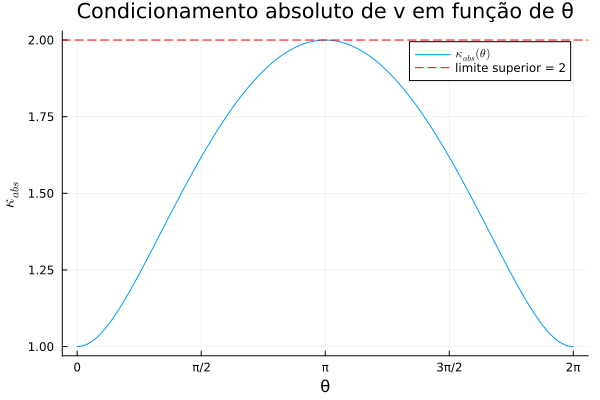

In [59]:
function jacobiano(x)
    n = length(x)
    norm_x = norm(x)
    # J = I - e1 * x' / ||x||
    J = Matrix{Float64}(I, n, n)
    J[1, :] -= x / norm_x # modifica somente a primeira linha
    return J
end

function x_cos_sin(θ, size, tipo) # parametro size para a proxima questão, não necessariamente usado aqui
    return tipo[cos(θ), sin(θ)]
end

thetas = range(0, 2π, length = 200)
cond_ = []
for θ in thetas
    x = x_cos_sin(θ, 2, Float64)
    push!(cond_, maximum(svdvals(jacobiano(x)))
)
end
println("valor maximo: ", maximum(cond_))

plot(thetas, cond_,
    xlabel = "θ",
    ylabel = L"κ_{abs}",
    title  = "Condicionamento absoluto de v em função de θ",
    label  = L"κ_{abs}(θ)",
    xticks = ([0, π/2, π, 3π/2, 2π], ["0", "π/2", "π", "3π/2", "2π"]),
    hline! = [2.0],  # linha de referência no limite superior
)
hline!([2.0], label="limite superior = 2", linestyle=:dash, color=:red)

Nesse caso, quanto mais longe $x$ está de $e_1$ mais $v$ "estica" as perturbações e $\theta = \pi$ é o ponto mais distante de $e_1$ no círculo.

---

$(e)$ Uma ideia seria testar com vetores rodando o $\mathbb{R}^2$

In [60]:
function x_randn(parameter, size, tipo)
    return randn(tipo, Int(size))
end

function testar_reflector(parameter, size, tipo, func)
    x = func(parameter, size, tipo)
    v, β = reflector(x)
    
    # verifica tipos
    if (eltype(x) != eltype(v)) || (eltype(x) != typeof(β)) 
        error("tipos diferentes")
    end

    # verifica que Qx ≈ ||x||e1
    Qx = x - β * (v' * x) * v   # aplica o refletor sem montar a matriz
    e1 = zeros(tipo, size)
    e1[1] = one(tipo)
    return norm(Qx - norm(x) * e1)

end

# teste com x_cos_sin
err_cos_sin_f32 = []
err_cos_sin_f64 = []

for θ in thetas
    push!(err_cos_sin_f32, testar_reflector(θ, 2, Float32, x_cos_sin))
    push!(err_cos_sin_f64, testar_reflector(θ, 2, Float64, x_cos_sin))
end

# teste com randn
err_randn_f32 = []
err_randn_f64 = []
sizes = 50:50:5000
for s in sizes
    push!(err_randn_f32, testar_reflector(0, s, Float32, x_randn))
    push!(err_randn_f64, testar_reflector(0, s, Float64, x_randn))
end

println("Float32")
println("eps da máquina: ", eps(Float32))
println("erro máximo com x = (cos(θ), sin(θ)) - Float32: ", maximum(err_cos_sin_f32))
println("erro médio com x = (cos(θ), sin(θ)) - Float32: ", mean(err_cos_sin_f32))
println()
println("erro máximo com x = randn(n) - Float32: ", maximum(err_randn_f32))
println("erro médio com x = randn(n) - Float32: ", mean(err_randn_f32))

println("\n")

println("Float64")
println("eps da máquina: ", eps(Float64))
println("erro máximo com x = (cos(θ), sin(θ)) - Float64: ", maximum(err_cos_sin_f64))
println("erro médio com x = (cos(θ), sin(θ)) - Float64: ", mean(err_cos_sin_f64))
println()
println("erro máximo com x = randn(n) - Float64: ", maximum(err_randn_f64))
println("erro médio com x = randn(n) - Float64: ", mean(err_randn_f64))

Float32
eps da máquina: 1.1920929e-7
erro máximo com x = (cos(θ), sin(θ)) - Float32: 8.419156e-7
erro médio com x = (cos(θ), sin(θ)) - Float32: 9.211051e-8

erro máximo com x = randn(n) - Float32: 0.0001258937
erro médio com x = randn(n) - Float32: 2.0245796e-5


Float64
eps da máquina: 2.220446049250313e-16
erro máximo com x = (cos(θ), sin(θ)) - Float64: 3.219646771412954e-15
erro médio com x = (cos(θ), sin(θ)) - Float64: 1.8103080084179437e-16

erro máximo com x = randn(n) - Float64: 3.9976568904378974e-13
erro médio com x = randn(n) - Float64: 4.903994839387855e-14


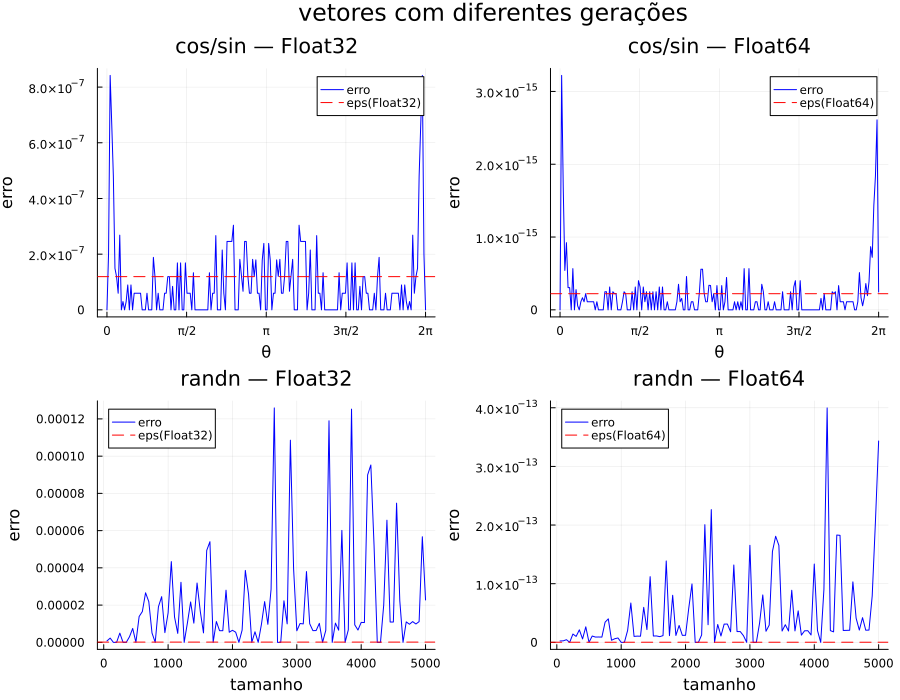

In [61]:
p1 = plot(thetas, err_cos_sin_f32,
    title  = "cos/sin — Float32",
    xlabel = "θ",
    ylabel = "erro",
    xticks = ([0, π/2, π, 3π/2, 2π], ["0", "π/2", "π", "3π/2", "2π"]),
    hline! = [eps(Float32)],
    label  = "erro",
    color  = :blue)
hline!(p1, [eps(Float32)], label="eps(Float32)", linestyle=:dash, color=:red)

p2 = plot(thetas, err_cos_sin_f64,
    title  = "cos/sin — Float64",
    xlabel = "θ",
    ylabel = "erro",
    xticks = ([0, π/2, π, 3π/2, 2π], ["0", "π/2", "π", "3π/2", "2π"]),
    label  = "erro",
    color  = :blue)
hline!(p2, [eps(Float64)], label="eps(Float64)", linestyle=:dash, color=:red)

p3 = plot(sizes, err_randn_f32,
    title  = "randn — Float32",
    xlabel = "tamanho",
    ylabel = "erro",
    label  = "erro",
    color  = :blue)
hline!(p3, [eps(Float32)], label="eps(Float32)", linestyle=:dash, color=:red)

p4 = plot(sizes, err_randn_f64,
    title  = "randn — Float64",
    xlabel = "tamanho",
    ylabel = "erro",
    label  = "erro",
    color  = :blue)
hline!(p4, [eps(Float64)], label="eps(Float64)", linestyle=:dash, color=:red)

plot(p1, p2, p3, p4, layout=(2,2), size=(900,700), suptitle = "vetores com diferentes gerações")

Nos dois subsplots de cima, os erros ficam na ordem de $\epsilon$, com picos perto de $0$ e $2\pi$. Nesses valores $x \to e_1$, então $||y||_2 \to 0$. O denominador na fórmula de $\beta$ fica muito pequeno, amplificando o erro de arredondamento. Mas ainda assim com erros relativamente pequenos.

Nos dois prots de baixo vemos que o erro cresce com a dimensão, bem acima de $\epsilon$. Imagino que isso seja porque estamos somando $n$ termos com erros de arredondamento depois tirando a raiz quadrada, o que faria o erro crescer proporcional a $\sqrt{n}\epsilon$. Sendo assim, apenas um erro de ponto flutuante, não de instabilidade da função.

Nota-se também como a escolha de tipos influencia na precisão dos cálculos dessas funções.

---

$(f)$ Sabemos que para fazer a reflexão de $x$ em relação ao espaço no qual $v$ é ortgonal temos que subtrair de $x$ duas vezes a projeção de $x$ em $v$. Ou seja, $H = I - 2\frac{vv^*}{v^*v}$. Assim:
$$\beta = \frac{2}{v^*v}$$

In [62]:
function calc_beta(v)
    vv = v' * v

    # caso em que x está exatamente alinhado com e1: v = x - ||x||e1 = 0
    if iszero(vv)
        return zero(eltype(v))
    end
    
    return 2 / (vv)
end

calc_beta (generic function with 1 method)

In [63]:
function testar_calc_beta(parameter, size, tipo, func)
    x = func(parameter, size, tipo)
    v, β_reflector = reflector(x)
    β_calc = calc_beta(v)

    # verifica tipos
    if typeof(β_calc) != tipo
        error("tipo errado: $(typeof(β_calc)) != $tipo")
    end

    # erro usando β de calc_beta
    Qx = x - β_calc * (v' * x) * v
    e1 = zeros(tipo, Int(size))
    e1[1] = one(tipo)

    return norm(Qx - norm(x) * e1), abs(β_reflector - β_calc)
end

err_calc_f32 = []
err_calc_f64 = []
diff_β_f32 = []
diff_β_f64 = []

for θ in thetas
    err_32, diff_32 = testar_calc_beta(θ, 2, Float32, x_cos_sin)    
    err_64, diff_64 = testar_calc_beta(θ, 2, Float64, x_cos_sin)

    push!(err_calc_f32, err_32)
    push!(err_calc_f64, err_64)
    push!(diff_β_f32, diff_32)
    push!(diff_β_f64, diff_64)
end

println("Float32")
println("eps da máquina: ", eps(Float32))
println("erro máximo com x = (cos(θ), sin(θ)) - Float32: ", maximum(err_calc_f32))
println("erro médio com x = (cos(θ), sin(θ)) - Float32: ", mean(err_calc_f32))
println()
println("max| β_calc - β_reflector | - Float32: ", maximum(diff_β_f32))
println("mean| β_calc - β_reflector | - Float32: ", mean(diff_β_f32))

println("\n")

println("Float64")
println("eps da máquina: ", eps(Float64))
println("erro máximo com x = (cos(θ), sin(θ)) - Float64: ", maximum(err_calc_f64))
println("erro médio com x = (cos(θ), sin(θ)) - Float64: ", mean(err_calc_f64))
println()
println("max| β_calc - β_reflector | - Float64: ", maximum(diff_β_f64))
println("mean| β_calc - β_reflector | - Float64: ", mean(diff_β_f64))

Float32
eps da máquina: 1.1920929e-7
erro máximo com x = (cos(θ), sin(θ)) - Float32: 8.493662e-7
erro médio com x = (cos(θ), sin(θ)) - Float32: 9.825152e-8

max| β_calc - β_reflector | - Float32: 3.0517578e-5
mean| β_calc - β_reflector | - Float32: 5.197525e-7


Float64
eps da máquina: 2.220446049250313e-16
erro máximo com x = (cos(θ), sin(θ)) - Float64: 3.2127078775090467e-15
erro médio com x = (cos(θ), sin(θ)) - Float64: 1.8915648107618694e-16

max| β_calc - β_reflector | - Float64: 2.2737367544323206e-13
mean| β_calc - β_reflector | - Float64: 2.4313884239290927e-15


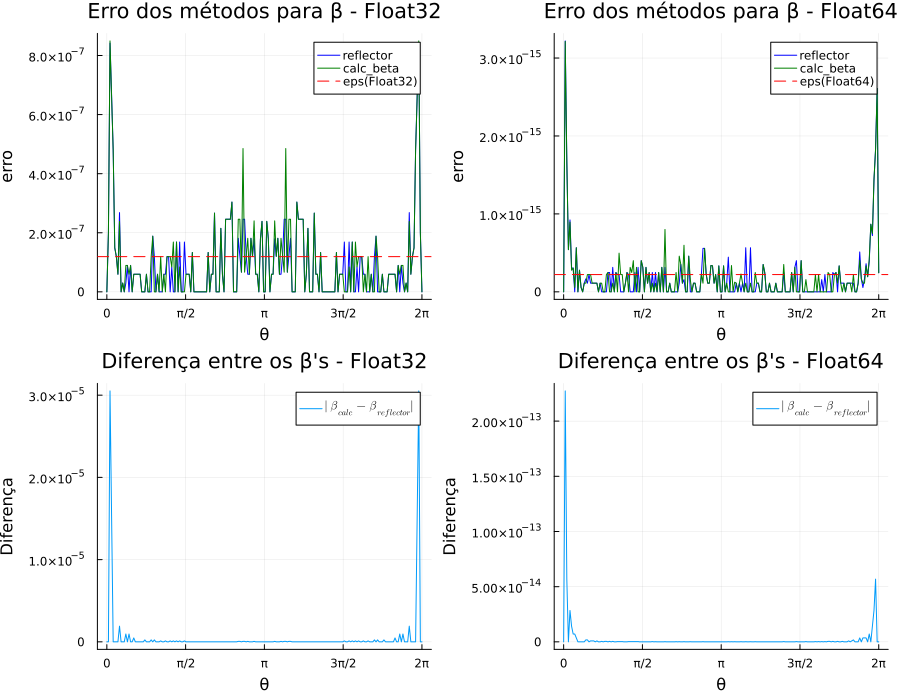

In [64]:
p1 = plot(thetas, err_cos_sin_f32, 
    label= "reflector", 
    title = "Erro dos métodos para β - Float32",
    xlabel = "θ",
    ylabel = "erro",
    xticks = ([0, π/2, π, 3π/2, 2π], ["0", "π/2", "π", "3π/2", "2π"]),
    color=:blue)
plot!(p1, thetas, err_calc_f32, 
    label="calc_beta", color=:green)
hline!(p1, [eps(Float32)], label="eps(Float32)", linestyle=:dash, color=:red)

p2 = plot(thetas, err_cos_sin_f64, 
    label="reflector",
    title = "Erro dos métodos para β - Float64",
    xticks = ([0, π/2, π, 3π/2, 2π], ["0", "π/2", "π", "3π/2", "2π"]),
    xlabel = "θ",
    ylabel = "erro",
    color=:blue)
plot!(p2, thetas, err_calc_f64, label="calc_beta", color=:green)
hline!(p2, [eps(Float64)], label="eps(Float64)", linestyle=:dash, color=:red)

p3 = plot(thetas, diff_β_f32,
    label = L"|β_{calc} - β_{reflector}|",
    title = "Diferença entre os β's - Float32",
    xticks = ([0, π/2, π, 3π/2, 2π], ["0", "π/2", "π", "3π/2", "2π"]),
    xlabel = "θ",
    ylabel = "Diferença")

p4 = plot(thetas, diff_β_f64,
    label = L"|β_{calc} - β_{reflector}|",
    title = "Diferença entre os β's - Float64",
    xticks = ([0, π/2, π, 3π/2, 2π], ["0", "π/2", "π", "3π/2", "2π"]),
    xlabel = "θ",
    ylabel = "Diferença",)
    

plot(p1,p2,p3,p4, layout = (2,2), size=(900,700))

Nos dois subplots de cima as curvas azul (reflector) e verde (calc_beta) estão praticamente sobrepostas nos dois tipos. Isso confirma o que o enunciado afirma: "Não há muita diferença ao calcular $\beta$ a partir de $x$ ou apenas de $v$".

Quanto a análise dos dois subplots de baixo, os $\beta 's$ calculados são identicos na maior parte do domínio. divergem ligeiramente quando temos $x \approx e_1$

---

$(g)$ (Bônus) Temos $v_1$ como uma função de $x$. O condicionamento relativo de $v_1$ é dado por:
$$k = \frac{||J_{v_1}||_2}{|v_1|/||x||_2}$$

$J_{v_1}$ já foi calculado anteriormente, é a primeira linha da matriz $J$:
$$J_{v_1} = \begin{pmatrix}
1-\frac{x_1}{||x||_2} & -\frac{x_2}{||x||_2} & -\frac{x_3}{||x||_2} & \cdots & -\frac{x_n}{||x||_2}
\end{pmatrix}$$

Precisaremos de um resultado importante:
$||a^*||_2 = ||a||_2$

Tome $x$ vetor unitário. Por Cauchy-Schartz 
$$||a^*x||_2 = |a^*x| < ||a||_2 ||x||_2 = ||a||_2$$

Seja $x = a/||a||_2$ (é unitário)
$$\frac{|a^*a|}{||a||_2} = \frac{||a||_2^2}{||a||_2} = ||a||_2$$

Aplicando isso no problema:
$$||J_{v_1}||_2^2 = \left(1 - \frac{x_1}{||x||_2}\right)^2 + \left(-\frac{x_2}{||x||_2}\right)^2 + \cdots + \left(-\frac{x_n}{||x||_2}\right)^2$$

$$ = 1 - 2\frac{x_1}{||x||_2} + \frac{||x||_2^2}{||x||_2^2} = 2\left(1-\frac{x_1}{||x||_2} \right)$$

Assim, substituindo:
$$k_{rel} = \sqrt{2\left(1-\frac{x_1}{||x||_2} \right)} \cdot \frac{||x||_2}{||x||_2 - x_1}$$

$$ = \sqrt{\frac{2(||x||_2 - x_1)}{||x||_2}} \cdot \frac{||x||_2}{||x||_2 - x_1} = \frac{\sqrt{2||x||_2}}{\sqrt{||x||_2-x_1}}$$

Quando $x \to e_1$, $x_1 \to ||x||_2$ temos $k_{rel} \to \infty$, mal condicionado relativamente.

Seguindo a mesma estratégia para $\beta$:
$$v_1 = x - ||x||_2 = \frac{(x - ||x||_2)(x_1 + ||x||_2)}{x_1 + ||x||_2} = \frac{x_1^2 - ||x||^2}{x_1 + ||x||_2} = \frac{-||y||_2^2}{x_1 + ||x||_2}$$

denominador sem cancelamento númerico e $||y||^2$ calculado diretamente também sem cancelamento.


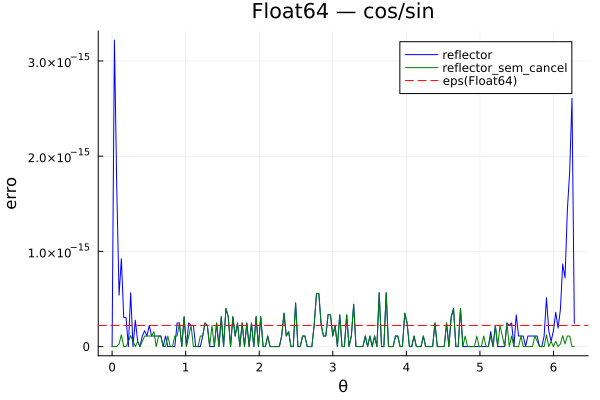

In [65]:
function reflector_sem_cancel(x)
    norm_x = norm(x)
    norm_y2 = sum(xi^2 for xi in x[2:end])
    
    # se está exatamente alinhado com e1
    if norm_y2 == 0
        return zeros(eltype(x), length(x)), zero(eltype(x))
    end
    
    v = copy(x)
    
    if x[1] >= 0
        # fórmula estável para v1
        v[1] = -norm_y2 / (x[1] + norm_x)
        β = (norm_x + x[1]) / (norm_x * norm_y2)

    else
        v[1] = x[1] - norm_x  # sem cancelamento quando x1 < 0
        β = one(eltype(x)) / (norm_x * (norm_x - x[1]))
    end
    
    return v, β
end

function comparar_reflector(parameter, size, tipo, func)
    x = func(parameter, size, tipo)
    v, β = reflector_sem_cancel(x)
    
    if (eltype(x) != eltype(v)) || (eltype(x) != typeof(β))
        error("tipos diferentes")
    end
    
    Qx = x - β * (v' * x) * v
    e1 = zeros(tipo, Int(size))
    e1[1] = one(tipo)
    return norm(Qx - norm(x) * e1)
end

# teste com x_cos_sin
err_estavel_f32 = []
err_estavel_f64 = []
for θ in thetas
    push!(err_estavel_f32, comparar_reflector(θ, 2, Float32, x_cos_sin))
    push!(err_estavel_f64, comparar_reflector(θ, 2, Float64, x_cos_sin))
end

p1 = plot(thetas, err_cos_sin_f32,
    label="reflector", color=:blue,
    title="Float32 — cos/sin",
    xlabel="θ", ylabel="erro")
plot!(p1, thetas, err_estavel_f32,
    label="reflector_sem_cancel", color=:green)
hline!(p1, [eps(Float32)], label="eps(Float32)", linestyle=:dash, color=:red)

p2 = plot(thetas, err_cos_sin_f64,
    label="reflector", color=:blue,
    title="Float64 — cos/sin",
    xlabel="θ", ylabel="erro")
plot!(p2, thetas, err_estavel_f64,
    label="reflector_sem_cancel", color=:green)
hline!(p2, [eps(Float64)], label="eps(Float64)", linestyle=:dash, color=:red)


Utilizando o mesmo estilo de gráfico anteriormente, podemos notar que o erro aumenta quando quando estamos quase alinhados com $e_1$ no refletor criado na questão $(c)$ mas isso não acontece com o novo refletor criado nessa questão, mostrando a importância de preocupar com o cancelamento numérico ao implementar obejtos matematicos computacionalmente, mesmo que na teoria as fórmulas sejam equivalentes.

---

# Questão 2. Forma de Hessemberg

Como (a), (b) e (c) seguem um fluxo, será feita somente uma vez a função com as ideias construídas em cada item.

$(a)$ Aplicar um refletor significa:
$$Q_{v}b = (I −\beta vv^∗)b = b - (v^*b)v$$

Como $v^*b$ é um escalar não é nem necessário nem eficiente calcular a matriz de reflexão.

$(b)$ Se $v$ tem dimensão $k$ e $b$ tem dimensão $n>k$, o refletor age somente nas primeiras $k$ entradas de $b$, deixando o resto intacto.

$(c)$ Em Julia podemos criar a mesma função mas com argumentos de natureza diferentes. Uma matriz $A_{m\times n}$ pode ser vista como conjunto $n$ vetores:
$$A =
\begin{bmatrix}
| & | & & | \\
a_1 & a_2 & \cdots & a_n \\
| & | & & |
\end{bmatrix}
$$

Aplicar $Q_{v}$ em A é basicamente aplicar em cada coluna:
$$A =
\begin{bmatrix}
| & | & & | \\
Q_v a_1 & Q_v a_2 & \cdots & Q_v a_n \\
| & | & & |
\end{bmatrix}
$$

In [66]:
function apply_reflector(v, β, b::Vector)
    k = length(v)
    
    # adaptação: v'b só nas primeiras k componentes de b
    result = copy(b)
    result[1:k] -= β * (v' * b[1:k]) * v
    return result
end

function apply_reflector(v, β, A::Matrix)
    k = length(v)
    
    result = copy(A)
    result[1:k, :] -= β * v * (v' * A[1:k, :])
    return result
end

apply_reflector (generic function with 2 methods)

Aqui temos uma seção de testes interessantes:

In [67]:
# teste 1: mesma dimensão, resultado correto
for n in [2, 5, 10, 50, 100, 200, 500, 1000]
    x = randn(n)
    v, β = reflector(x)
    Qx = apply_reflector(v, β, x)
    e1 = zeros(n); e1[1] = 1.0
    println("n=$n, erro = ", norm(Qx - norm(x)*e1))
end

n=2, erro = 3.1401849173675503e-16
n=5, erro = 2.7894008272968645e-16
n=10, erro = 6.10671943472214e-16
n=50, erro = 0.0
n=100, erro = 2.7645745474427814e-15
n=200, erro = 7.68763088124998e-15
n=500, erro = 2.637913703407672e-14
n=1000, erro = 1.7714455965132007e-14


In [68]:
# teste 2: b maior que v, componentes além de k inalteradas
for (k, n) in [(2,5), (3,10), (5,20), (29,30), (2, 2000)]
    x = randn(k)
    v, β = reflector(x)
    b = randn(n)
    Qb = apply_reflector(v, β, b)
    println("k=$k, n=$n, componentes inalteradas: ", norm(Qb[k+1:end] - b[k+1:end]))
end

k=2, n=5, componentes inalteradas: 0.0
k=3, n=10, componentes inalteradas: 0.0
k=5, n=20, componentes inalteradas: 0.0
k=29, n=30, componentes inalteradas: 0.0
k=2, n=2000, componentes inalteradas: 0.0


In [69]:
# teste 3: Q² = I
for n in [2, 5, 10, 50, 100, 200, 500, 1000]
    x = randn(n)
    v, β = reflector(x)
    b = randn(n)
    QQb = apply_reflector(v, β, apply_reflector(v, β, b))
    println("n=$n, ||Q²b - b|| = ", norm(QQb - b))
end

n=2, ||Q²b - b|| = 6.245004513516506e-17
n=5, ||Q²b - b|| = 2.618455766672135e-16
n=10, ||Q²b - b|| = 1.412282265928462e-16
n=50, ||Q²b - b|| = 2.0194446407960708e-16
n=100, ||Q²b - b|| = 6.097941652824874e-16
n=200, ||Q²b - b|| = 9.458924742486546e-16
n=500, ||Q²b - b|| = 7.542851851648343e-15
n=1000, ||Q²b - b|| = 2.1874927147195476e-15


In [70]:
# teste 4: Q preserva norma
for n in [2, 5, 10, 50, 100, 200, 500, 1000]
    x = randn(n)
    v, β = reflector(x)
    b = randn(n)
    println("n=$n, ||Qb|| - ||b|| = ", abs(norm(apply_reflector(v, β, b)) - norm(b)))
end

n=2, ||Qb|| - ||b|| = 5.551115123125783e-17
n=5, ||Qb|| - ||b|| = 0.0
n=10, ||Qb|| - ||b|| = 0.0
n=50, ||Qb|| - ||b|| = 8.881784197001252e-16
n=100, ||Qb|| - ||b|| = 0.0
n=200, ||Qb|| - ||b|| = 0.0
n=500, ||Qb|| - ||b|| = 0.0
n=1000, ||Qb|| - ||b|| = 0.0


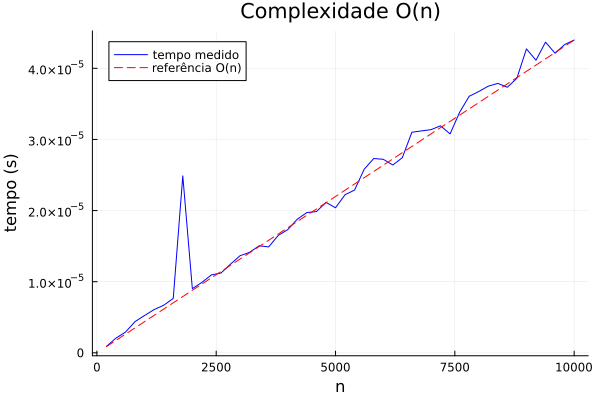

In [71]:
# ========================================================
# Célula demora em torno de 50s pra rodar
# ========================================================
using BenchmarkTools

# teste O(n)
ns = 200:200:10000
tempos_v = []
for n in ns
    x = randn(n)
    v, β = reflector(x)
    b = randn(n)
    t = @belapsed apply_reflector($v, $β, $b) seconds=0.05
    push!(tempos_v, t)
end

p1 = plot(ns, tempos_v,
    label="tempo medido",
    title="Complexidade O(n)",
    xlabel="n", ylabel="tempo (s)",
    color=:blue)
plot!(p1, ns, ns * tempos_v[end]/ns[end],
    label="referência O(n)",
    linestyle=:dash, color=:red)

Como esperado, o gráfico segue uma curva quase linear.

---

$(d)$ Calculando $AQ_v$

$$AQ_v = A(I - \beta vv^*) = A - \beta (Av)v^*$$

para que esse produto seja definido precisamos que as dimensões sejam compatíveis, ou seja, $v_{n \times 1}$ e $A_{m \times n}$. Mas como na prática armazenamos somente as primeiras k componentes não nulas precisamos fazer um ajuste. O refletor a direita vai agir somente nas $k$ primeiras colunas de $A$.

In [72]:
function rev_apply_reflector(v, β, A)
    k = length(v)
    result = copy(A)
    result[:, 1:k] -= β * (A[:, 1:k] * v) * v'
    return result
end

rev_apply_reflector (generic function with 1 method)

$(e)$

In [73]:
function to_hessenberg(A; matrix_Q=false)
    n = size(A, 1)
    H = copy(A)
    reflectors = []
    
    for j in 1:n-2
        x = H[j+1:n, j]
        v, β = reflector(x)
        push!(reflectors, (v, β))
        
        H[j+1:n, j:n] = apply_reflector(v, β, H[j+1:n, j:n])
        H[1:n, j+1:n] = rev_apply_reflector(v, β, H[1:n, j+1:n])
    end
    
    if matrix_Q
        Q = Matrix{eltype(A)}(I, n, n)
        for (j, (v, β)) in enumerate(reflectors)
            # Q_j age no bloco j+1:n
            # aplicamos Q_j pela direita em Q: Q = Q * Q_j
            Q[:, j+1:n] = rev_apply_reflector(v, β, Q[:, j+1:n])
        end
        
        return reflectors, H, Q
    end
    
    return reflectors, H
end

to_hessenberg (generic function with 1 method)

$(f)$

In [74]:
function testar_hessenberg(n, simetrica)
    A = randn(n, n)
    if simetrica
        A = A + A'  # torna simétrica
    end
    
    reflectors, H, Q = to_hessenberg(A, matrix_Q=true)
    
    erro_A = norm(A - Q * H * Q')
    erro_Q = norm(Q' * Q - I)
    
    return erro_A, erro_Q
end

for n in [2, 10, 100]
    for simetrica in [true, false]
        erros_A = []
        erros_Q = []
        for _ in 1:100 # testando 100 matrizes para cada configuração
            erro_A, erro_Q = testar_hessenberg(n, simetrica)
            push!(erros_A, erro_A)
            push!(erros_Q, erro_Q)
        end
        println("n = ", n, " | Simétrica: ", simetrica)
        println("||A - QHQ*|| -- max: ", maximum(erros_A), " | média: ", mean(erros_A))
        println("||Q*Q - I|| -- max: ", maximum(erros_Q), " | média: ", mean(erros_Q))
        println()
    end
end

n = 2 | Simétrica: true
||A - QHQ*|| -- max: 0.0 | média: 0.0
||Q*Q - I|| -- max: 0.0 | média: 0.0

n = 2 | Simétrica: false
||A - QHQ*|| -- max: 0.0 | média: 0.0
||Q*Q - I|| -- max: 0.0 | média: 0.0

n = 10 | Simétrica: true
||A - QHQ*|| -- max: 1.556134639273918e-14 | média: 9.760862409307978e-15
||Q*Q - I|| -- max: 2.3381644161011734e-15 | média: 1.583476094607534e-15

n = 10 | Simétrica: false
||A - QHQ*|| -- max: 1.225507146286039e-14 | média: 6.744606122124048e-15
||Q*Q - I|| -- max: 2.9005061772414624e-15 | média: 1.5938661471211416e-15

n = 100 | Simétrica: true
||A - QHQ*|| -- max: 2.129924073928676e-13 | média: 1.7703021114816466e-13
||Q*Q - I|| -- max: 1.164321419411041e-14 | média: 1.0080812376385096e-14

n = 100 | Simétrica: false
||A - QHQ*|| -- max: 1.5263482729625051e-13 | média: 1.3043386816701073e-13
||Q*Q - I|| -- max: 1.1527426707241751e-14 | média: 1.0088346700502981e-14



Para $n = 2$ não há muito o que dizer pois já está na forma de Hessemberg, sendo assim o erro é 0.
Para as matrizes maiores, os erros estão pequenos sendo o erro obtido com matrizes $n = 100$ 10 vezes maior que o erro de $n = 10$. Em relação a simetria, os erros são da mesma ordem nos dois casos, mostrando que a função funciona corretamente para ambos os tipos de matriz.

---

# Questão 3. Exponenciais de matrizes

$(a)$ O polinômio característico é:
$$det(A- \lambda I) = det
\begin{pmatrix}
-\lambda & 1 \\
-\omega^2 & -\lambda 
\end{pmatrix}
= \lambda^2 + \omega^2 = 0
$$

$$\Rightarrow \lambda = \pm i\omega$$

Calculando os autovetores:
$$
\begin{bmatrix}
\mp i\omega & 1 \\
-\omega^2 & \mp i\omega 
\end{bmatrix}
\begin{bmatrix}
x \\
y 
\end{bmatrix}
= 0
\Rightarrow y = \pm i\omega x
$$

$$v_1 = 
\begin{bmatrix}
1 \\
\omega i 
\end{bmatrix},
v_2 =
\begin{bmatrix}
1 \\
-\omega i 
\end{bmatrix}$$

No Julia os autovetores são normalizados. Assim, temos a comparação entre os vetores encontrados analiticamente e os vetores encontrados pelo Julia nos gráficos abaixo

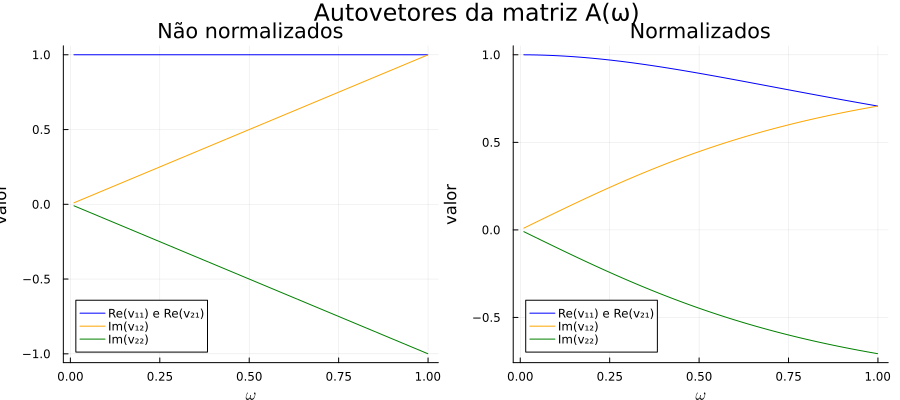

In [75]:
function eig_ordenado(ω)
    M = complex([0.0 1.0; -ω^2 0.0])
    vals = eigvals(M)
    vecs = eigvecs(M)
    idx = sortperm(imag.(vals), rev=true)
    return vals[idx], vecs[:, idx]
end

ω = LinRange(0.01, 0.999, 100)

vs = [eig_ordenado(w)[2] for w in ω]

v11 = ones(length(ω))
v12 = imag.(im .* ω)
v22 = imag.(-im .* ω)

# normalizados: direto do eigvecs
v11_n = real.([v[:, 1][1] for v in vs])
v12_n = imag.([v[:, 1][2] for v in vs])
v22_n = imag.([v[:, 2][2] for v in vs])

p1 = plot(ω, v11,
    label="Re(v₁₁) e Re(v₂₁)", color=:blue,
    xlabel=L"\omega", ylabel="valor",
    title="Não normalizados")
plot!(p1, ω, v12, label="Im(v₁₂)", color=:orange)
plot!(p1, ω, v22, label="Im(v₂₂)", color=:green)

p2 = plot(ω, v11_n,
    label="Re(v₁₁) e Re(v₂₁)", color=:blue,
    xlabel=L"\omega", ylabel="valor",
    title="Normalizados")
plot!(p2, ω, v12_n, label="Im(v₁₂)", color=:orange)
plot!(p2, ω, v22_n, label="Im(v₂₂)", color=:green)

plot(p1, p2, layout=(1,2), size=(900,400),
    plot_title="Autovetores da matriz A(ω)")

Os autovetores em função de ω

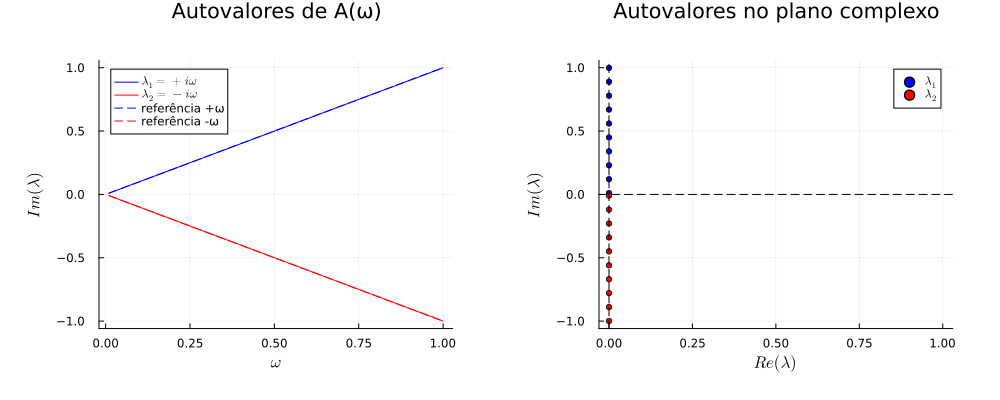

In [76]:
ω = LinRange(0.01, 0.999, 10)

λs = [eig_ordenado(w)[1] for w in ω]

# grafico 1: parte imaginaria em funcao de omega
p1 = plot(ω, imag.([λ[1] for λ in λs]),
    label=L"\lambda_1 = +i\omega", color=:blue,
    title="Autovalores de A(ω)",
    xlabel=L"\omega", ylabel=L"Im(\lambda)")
plot!(p1, ω, imag.([λ[2] for λ in λs]),
    label=L"\lambda_2 = -i\omega", color=:red)
plot!(p1, ω, collect(ω),
    label="referência +ω", linestyle=:dash, color=:blue)
plot!(p1, ω, -collect(ω),
    label="referência -ω", linestyle=:dash, color=:red)

# grafico 2: plano complexo — parte real vs imaginaria
p2 = scatter(zeros(length(ω)), imag.([λ[1] for λ in λs]),
    label=L"\lambda_1", color=:blue, markersize=3,
    title="Autovalores no plano complexo",
    xlabel=L"Re(\lambda)", ylabel=L"Im(\lambda)")
scatter!(p2, zeros(length(ω)), imag.([λ[2] for λ in λs]),
    label=L"\lambda_2", color=:red, markersize=3)
vline!(p2, [0.0], color=:black, linestyle=:dash, label="")
hline!(p2, [0.0], color=:black, linestyle=:dash, label="")

using Plots.PlotMeasures

plot(p1, p2, layout=(1,2), size=(1000,400), 
    left_margin=10mm, right_margin=10mm, 
    bottom_margin=10mm, top_margin=10mm)

---

$(b)$ O condicionamento de uma matriz é dado por $k(A) = \sigma_{max}/\sigma_{min}$. Calculando os valores singulares:
$$A^*A =
\begin{bmatrix}
0 & -\omega^2 \\
1 & 0 
\end{bmatrix}
\begin{bmatrix}
0 & 1 \\
-\omega^2 & 0 
\end{bmatrix}
=
\begin{bmatrix}
\omega^4 & 0 \\
0 & 1 
\end{bmatrix}
$$

Matriz diagonal na qual os autovalores são os elementos da diagonal. No intervalo $[0,1]$ temos $\omega^2 \leq 1$, logo:
$$k(A) = \frac{1}{\omega^2}$$

A medida que $\omega \to 0^+$ temos $k \to \infty$, $A$ fica cada vez mais mal condicionada.

Agora iremos calcular condicionamento de $P$ matriz de autovetores

$$P^*P = 
\begin{bmatrix}
1 & -\omega i \\
1 & \omega i
\end{bmatrix}

\begin{bmatrix}
1 & 1 \\
\omega i & -\omega i
\end{bmatrix}
=
\begin{bmatrix}
1 + \omega^2 & 1 - \omega^2 \\
1 - \omega^2 & 1 + \omega ^2
\end{bmatrix}
$$

os autovalores de $P^*P$
$$det
\begin{pmatrix}
1 - \omega^2 - \lambda & 1 + \omega^2 \\
1 + \omega^2 & 1 - \omega ^2 - \lambda
\end{pmatrix} = (1 + \omega^2 - \lambda)^2 - (1 - \omega^2)^2$$

$$ = \lambda^2 - 2(1 + \omega^2)\lambda + 4\omega^2 = 0$$

$$\Rightarrow \lambda_1 = 2, \lambda_2 = 2\omega^2$$

Como aqui estamos interessados no intervalo $[0,1]$, $\omega^2 < 2$. assim temos:
$$k(P) = \frac{1}{\omega}$$

Da mesma forma, quando $\omega \to 0^+$ temos $k \to \infty$, a matriz de autovetores tambem fica mal condicionada.

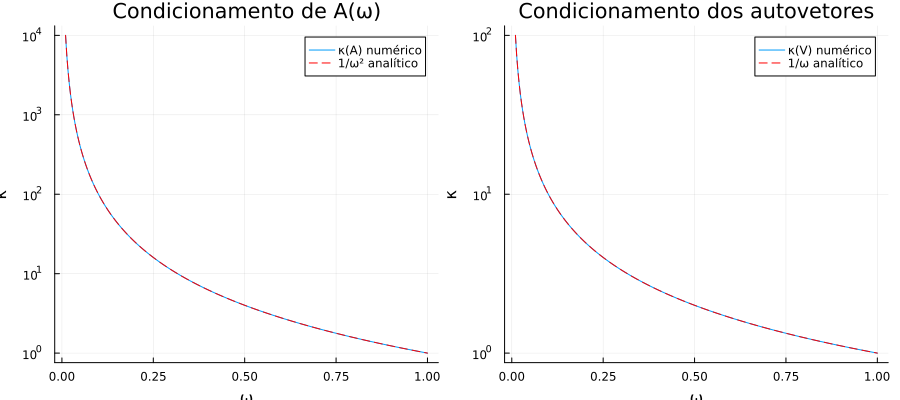

In [77]:
omegas = range(0.01, 1, length=300)  # evitamos ω=0 para não ter 1/0

cond_A = [cond([0 1; -ω^2 0]) for ω in omegas]
cond_P = [cond(eigvecs(complex([0.0 1.0; -ω^2 0.0]))) for ω in omegas]

p1 = plot(omegas, cond_A,
    label = "κ(A) numérico",
    title = "Condicionamento de A(ω)",
    xlabel = "ω", ylabel = "κ")
plot!(p1, omegas, 1 ./ omegas.^2,
    label = "1/ω² analítico",
    linestyle = :dash, color = :red)

p2 = plot(omegas, cond_P,
    label = "κ(V) numérico",
    title = "Condicionamento dos autovetores",
    xlabel = "ω", ylabel = "κ")
plot!(p2, omegas, 1 ./ omegas,
    label = "1/ω analítico",
    linestyle = :dash, color = :red)

plot(p1, p2, layout=(1,2), size=(900,400), yscale=:log10)

Como esperado, a linha azul segue o comportamento teórico encontrado anteriormente.

---

$(c)$ (Bônus) primeiramente mostraremos que $A(\omega)^2 = -\omega^2I$:
$$\begin{bmatrix}
0 & 1 \\
-\omega^2 & 0
\end{bmatrix}
\begin{bmatrix}
0 & 1 \\
-\omega^2 & 0
\end{bmatrix}
=
\begin{bmatrix}
-\omega^2 & 0 \\
0 & -\omega^2
\end{bmatrix} = -\omega^2I$$

Precisamos calcular as potências de $A(\omega)$:
$$A(\omega)^0 = I$$
$$A(\omega)^2 = -\omega^2I$$
$$A(\omega)^3 = -\omega^2A(\omega)$$
$$A(\omega)^4 = -\omega^2A(\omega)^2 = \omega^4I$$

Temos aqui um padrão:
* $A(\omega)^{2k} = (-\omega^2)^kI$
* $A(\omega)^{2k + 1} = (-\omega^2)^kA(\omega)$

Calculando a exponencial:
$$e^{tA(\omega)} = \sum_{k = 0}^\infty \frac{t^kA(\omega)^k}{k!} = I + \frac{tA(\omega)}{1!} + \frac{t^2(-\omega^2)I}{2!} + \frac{t^3(-\omega^2)A(\omega)}{3!} + \frac{t^4(-\omega^2)^2I}{4!} + \cdots$$

Separaremos termos pares e ímapares. Para os termos pares:
$$I(1 - \frac{(t\omega)^2}{2!} + \frac{(t\omega)^4}{4!} - \frac{(t\omega)^6}{6!} + \cdots) = Icos(\omega t)$$

Para os termos ímpares:
$$A(\omega)(\frac{t}{1!} - \frac{t^3\omega^2}{3!} + \frac{t^5\omega^4}{5!} - \frac{t^7\omega^6}{7!} + \cdots) = \frac{A(\omega)}{\omega}(\frac{\omega t}{1!} - \frac{(t\omega)^3}{3!} + \frac{(t\omega)^5}{5!} - \frac{(t\omega)^7}{7!} + \cdots) = \frac{sin(\omega t)}{\omega} A(\omega)$$

Sendo assim:
$$e^{tA(\omega)} = cos(\omega t)I + \frac{sin(\omega t)}{\omega} A(\omega)$$

Quando $\omega \to 0^+$ temos $A(0) = \begin{bmatrix} 0 & 1 \\ 0 & 0 \end{bmatrix}$ nilpotente de indice $2$, ou seja, $A(0)^2 = 0$. Logo
$$e^{tA(0)} = I + tA(0) = 
\begin{bmatrix}
1 & t \\
0 & 1
\end{bmatrix}$$

pela formula, precisamos de dois resultados importantes:
* $\lim_{\omega \to 0} cos(\omega t) = 1$
* $\lim_{\omega \to 0} \frac{sin(\omega t)}{w} = t$

$$\lim_{\omega \to 0} \left( cos(\omega t)I + \frac{sin(\omega t)}{\omega} A(\omega) \right) = I + tA(\omega) = 
\begin{bmatrix}
1 & t \\
0 & 1
\end{bmatrix}$$

Temos portanto o mesmo resultado!

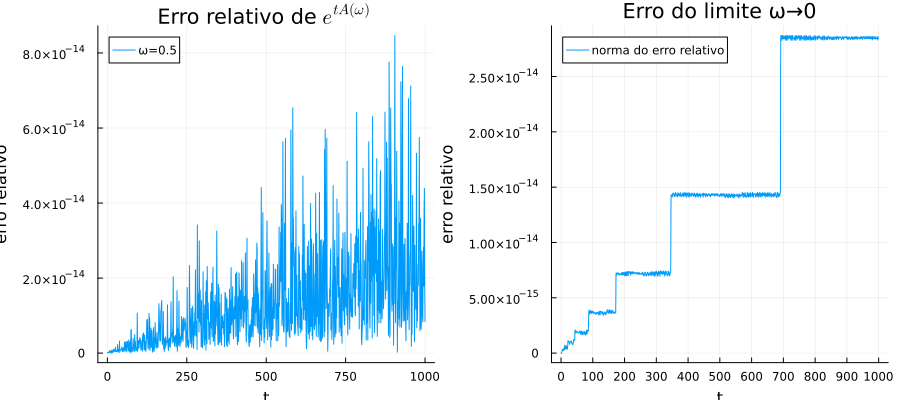

In [78]:
A(ω) = [0.0 1.0; -ω^2 0.0]

# fórmula analítica
exp_analitico(ω, t) = cos(ω*t)*I + sin(ω*t)/ω * A(ω)

# limite quando ω → 0
exp_limite(t) = [1.0 t; 0.0 1.0]

ts = range(0.01, 1000, length=1000)
ωs = [0.5]

p1 = plot(title=L"Erro relativo de $e^{tA(ω)}$", xlabel="t", ylabel="erro relativo")
for ω in ωs
    erros = [norm(exp_analitico(ω, t) - exp(t*A(ω))) / norm(exp(t*A(ω))) for t in ts]
    plot!(p1, ts, erros, label="ω=$ω")
end

erros_lim = [norm(exp_limite(t) - exp(t*A(0.0))) / norm(exp(t*A(0.0))) for t in ts]

p2 = plot(ts, erros_lim,
    title="Erro do limite ω→0",
    xlabel="t", ylabel="erro relativo",
    label="norma do erro relativo",
    xticks = 0:100:1000)


plot(p1, p2, layout=(1,2), size=(900,400))

No primeiro subplot, o erro cresce com $t$, mas ainda perto de $eps(Float64)$. Acredito ser por acúmulo de erros de arredondamento. E temos um comportamento oscilatório que vem de $sin$ e $cos$ na fórmula. No gráfico a direita, onde analisamos o comportamento quando estamos vendo o limite $\omega \to 0^+$, os erros crescem em escada, onde cada degrau parecem ocorrer aproximadamente no dobro do anterior:
$$\approx 90 \rightarrow \approx 175 \rightarrow \approx 350 \rightarrow \approx 700$$

Acontece por causa da representação do ponto flutuante, na qual o degrau é onde a representação binária muda de escala.

---